# DeepWalk neuronal — GCN enrichi (features structurelles)
Feature matrix riche (5 features) + GCN 3 couches + loss skip-gram

---

## 1 — Construction de la feature matrix enrichie

In [62]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from torch_geometric.nn import GCNConv
from torch_geometric.utils import to_undirected
from torch_cluster import random_walk
import warnings
warnings.filterwarnings('ignore')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device : {device}')

Device : cpu


In [64]:
# ── Chargement & encodage ─────────────────────────────────────────────────────
DATA_PATH = 'part_02.csv'
df = pd.read_csv(DATA_PATH)
df_agg = df.groupby(['user_id', 'original_author'], as_index=False)['nb_retweeted'].sum()

le = LabelEncoder()
all_ids = pd.concat([df_agg['user_id'], df_agg['original_author']]).unique()
le.fit(all_ids)
df_agg['src'] = le.transform(df_agg['user_id'])
df_agg['dst'] = le.transform(df_agg['original_author'])
N = len(le.classes_)
np.save('label_encoder_classes.npy', le.classes_)

print(f'Nœuds : {N:,}  |  Arcs : {len(df_agg):,}')

Nœuds : 146,141  |  Arcs : 214,148


In [65]:
# ── Construction du graphe NetworkX (non-orienté, pondéré) ────────────────────
print('Construction du graphe NetworkX...')
G_nx = nx.Graph()
G_nx.add_nodes_from(range(N))
G_nx.add_weighted_edges_from(
    zip(df_agg['src'], df_agg['dst'], df_agg['nb_retweeted'])
)
print(f'Graphe : {G_nx.number_of_nodes():,} nœuds, {G_nx.number_of_edges():,} arcs')

Construction du graphe NetworkX...
Graphe : 146,141 nœuds, 214,148 arcs


In [66]:
# ── Calcul des features structurelles ────────────────────────────────────────
# Toutes vectorisées ou via dict NetworkX pour éviter les boucles Python
print('Calcul des features structurelles (2-4 min)...')

nodes = list(range(N))

# 1. Degré (nombre de voisins)
degree_dict = dict(G_nx.degree())
degree = np.array([degree_dict.get(i, 0) for i in nodes], dtype=float)

# 2. Force (somme des poids des arcs — nb_retweeted)
strength_dict = dict(G_nx.degree(weight='weight'))
strength = np.array([strength_dict.get(i, 0) for i in nodes], dtype=float)

# 3. Coefficient de clustering local
# Mesure si les voisins d'un nœud se connaissent entre eux → signature de communauté
print('  → clustering...')
clustering_dict = nx.clustering(G_nx)
clustering = np.array([clustering_dict.get(i, 0) for i in nodes], dtype=float)

# 4. Degré moyen des voisins (ego-network density)
# Un nœud dans une communauté dense a des voisins eux-mêmes bien connectés
print('  → average neighbor degree...')
avg_neighbor_deg_dict = nx.average_neighbor_degree(G_nx)
avg_neighbor_deg = np.array([avg_neighbor_deg_dict.get(i, 0) for i in nodes], dtype=float)

# 5. Log-force normalisée (capture les hubs sans les écraser)
log_strength = np.log1p(strength)

# 6. Ratio force/degré (poids moyen par arc — intensité de la relation)
ratio_strength_degree = np.where(degree > 0, strength / degree, 0)

print('Features calculées.')
features_raw = np.column_stack([
    degree,
    clustering,
    avg_neighbor_deg,
    log_strength,
    ratio_strength_degree
])
print(f'Shape features : {features_raw.shape}')  # (N, 5)

Calcul des features structurelles (2-4 min)...
  → clustering...
  → average neighbor degree...
Features calculées.
Shape features : (146141, 5)


In [67]:
# ── Normalisation StandardScaler ──────────────────────────────────────────────
scaler = StandardScaler()
features_scaled = scaler.fit_transform(features_raw)
x_rich = torch.tensor(features_scaled, dtype=torch.float)

print(f'Feature matrix : {x_rich.shape}')
print(pd.DataFrame(features_raw, columns=[
    'degree','clustering','avg_neighbor_deg','log_strength','ratio_str_deg'
]).describe().round(3))

Feature matrix : torch.Size([146141, 5])
           degree  clustering  avg_neighbor_deg  log_strength  ratio_str_deg
count  146141.000  146141.000        146141.000    146141.000     146141.000
mean        2.931       0.023           621.791         2.313          8.267
std        30.313       0.128           899.858         0.984         13.630
min         1.000       0.000             1.000         1.099          2.000
25%         1.000       0.000             9.222         1.609          4.000
50%         1.000       0.000           154.000         2.197          6.000
75%         2.000       0.000           892.000         2.708         10.000
max      3504.000       1.000          3504.000        11.619       1436.000


In [68]:
# ── edge_index PyG (non-orienté) ─────────────────────────────────────────────
edge_index_dir = torch.tensor(
    np.stack([df_agg['src'].values, df_agg['dst'].values]), dtype=torch.long
)
edge_index = to_undirected(edge_index_dir, num_nodes=N)
print(f'edge_index : {edge_index.shape}')

edge_index : torch.Size([2, 428296])


## 2 — Architecture GCN enrichie

In [70]:
class GCNEmbedder(nn.Module):
    """
    GCN 3 couches avec BatchNorm et skip connections.
    Les skip connections permettent au gradient de circuler
    même si une couche n'apporte pas d'information utile.
    Sortie : embeddings normalisés L2 (N × out_dim)
    """
    def __init__(self, in_dim, hidden_dim, out_dim):
        super().__init__()
        self.conv1 = GCNConv(in_dim,      hidden_dim)
        self.conv2 = GCNConv(hidden_dim,  hidden_dim)
        self.conv3 = GCNConv(hidden_dim,  out_dim)
        self.bn1   = nn.BatchNorm1d(hidden_dim)
        self.bn2   = nn.BatchNorm1d(hidden_dim)
        # Projection pour la skip connection (in_dim → hidden_dim)
        self.skip  = nn.Linear(in_dim, hidden_dim, bias=False)

    def forward(self, x, edge_index):
        # Couche 1
        h1 = F.relu(self.bn1(self.conv1(x, edge_index)))
        h1 = h1 + self.skip(x)          # skip connection
        h1 = F.dropout(h1, p=0.2, training=self.training)
        # Couche 2
        h2 = F.relu(self.bn2(self.conv2(h1, edge_index)))
        h2 = h2 + h1                     # skip connection
        h2 = F.dropout(h2, p=0.2, training=self.training)
        # Couche 3 — projection finale
        out = self.conv3(h2, edge_index)
        return F.normalize(out, p=2, dim=1)  # L2 norm


# Hyperparamètres
IN_DIM          = x_rich.shape[1]   # 5
HIDDEN_DIM      = 128
EMBED_DIM       = 32
WALK_LENGTH     = 20
CONTEXT_SIZE    = 5
WALKS_PER_NODE  = 5
NEG_SAMPLES     = 10
EPOCHS          = 200
LR              = 0.01
NODES_PER_BATCH = 500
MAX_PAIRS       = 4096

model     = GCNEmbedder(IN_DIM, HIDDEN_DIM, EMBED_DIM).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=1e-5)
scheduler = torch.optim.lr_scheduler.OneCycleLR(
    optimizer, max_lr=LR,
    steps_per_epoch=1, epochs=EPOCHS,
    pct_start=0.1
)

x_dev  = x_rich.to(device)
ei_dev = edge_index.to(device)
row    = ei_dev[0]
col    = ei_dev[1]

total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Paramètres : {total_params:,}')
print(model)

Paramètres : 22,560
GCNEmbedder(
  (conv1): GCNConv(5, 128)
  (conv2): GCNConv(128, 128)
  (conv3): GCNConv(128, 32)
  (bn1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (bn2): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (skip): Linear(in_features=5, out_features=128, bias=False)
)


## 3 — Loss skip-gram

In [72]:
def skipgram_loss(z, pos_pairs, neg_pairs):
    pos_score = (z[pos_pairs[:, 0]] * z[pos_pairs[:, 1]]).sum(dim=1)
    neg_score = (z[neg_pairs[:, 0]] * z[neg_pairs[:, 1]]).sum(dim=1)
    loss_pos  = F.binary_cross_entropy_with_logits(pos_score, torch.ones_like(pos_score))
    loss_neg  = F.binary_cross_entropy_with_logits(neg_score, torch.zeros_like(neg_score))
    return loss_pos + loss_neg


def generate_pairs(walk_tensor, context_size, neg_samples, n_nodes):
    pos_pairs = []
    num_walks, wlen = walk_tensor.shape
    for i in range(wlen):
        center = walk_tensor[:, i]
        for j in range(max(0, i - context_size), min(wlen, i + context_size + 1)):
            if j == i:
                continue
            pos_pairs.append(torch.stack([center, walk_tensor[:, j]], dim=1))
    pos_pairs = torch.cat(pos_pairs, dim=0)
    n = pos_pairs.shape[0]
    neg_ctx   = torch.randint(0, n_nodes, (n * neg_samples,), device=pos_pairs.device)
    neg_src   = pos_pairs[:, 0].repeat_interleave(neg_samples)
    neg_pairs = torch.stack([neg_src, neg_ctx], dim=1)
    return pos_pairs, neg_pairs

print('Fonctions définies.')

Fonctions définies.


## 4 — Entraînement

In [74]:
history = []
print(f"{'Epoch':>6}  {'Loss':>8}")
print('-' * 18)

for epoch in range(1, EPOCHS + 1):
    model.train()
    epoch_loss = 0.0
    n_batches  = 0
    node_perm  = torch.randperm(N, device=device)

    # ── z détaché : utilisé pour calculer les scores des paires ─────────────
    # Le gradient NE passe PAS par z à chaque batch intermédiaire
    # → pas de conflit avec optimizer.step()
    with torch.no_grad():
        z_detached = model(x_dev, ei_dev)  # (N, 32) — pas de graphe de calcul

    accum_loss = torch.tensor(0.0, device=device, requires_grad=False)

    for batch_start in range(0, N, NODES_PER_BATCH):
        batch_nodes = node_perm[batch_start: batch_start + NODES_PER_BATCH]
        start = batch_nodes.repeat(WALKS_PER_NODE)
        walks = random_walk(row, col, start, walk_length=WALK_LENGTH)

        pos_pairs, neg_pairs = generate_pairs(walks, CONTEXT_SIZE, NEG_SAMPLES, N)

        if pos_pairs.shape[0] > MAX_PAIRS:
            idx       = torch.randperm(pos_pairs.shape[0], device=device)[:MAX_PAIRS]
            pos_pairs = pos_pairs[idx]
            neg_pairs = neg_pairs[idx.repeat_interleave(NEG_SAMPLES)[:MAX_PAIRS * NEG_SAMPLES]]

        # Score sur z détaché — pas de gradient ici
        loss_val = skipgram_loss(z_detached, pos_pairs, neg_pairs)
        accum_loss = accum_loss + loss_val.detach()
        n_batches += 1
        del walks, pos_pairs, neg_pairs

    # ── Un seul forward + backward propre à la fin de l'epoch ───────────────
    optimizer.zero_grad()
    z = model(x_dev, ei_dev)  # forward avec graphe de calcul

    # On ré-échantillonne un batch représentatif pour le backward
    sample_nodes = torch.randperm(N, device=device)[:NODES_PER_BATCH * 4]
    start_sample = sample_nodes.repeat(WALKS_PER_NODE)
    walks_sample = random_walk(row, col, start_sample, walk_length=WALK_LENGTH)
    pos_s, neg_s = generate_pairs(walks_sample, CONTEXT_SIZE, NEG_SAMPLES, N)

    if pos_s.shape[0] > MAX_PAIRS:
        idx   = torch.randperm(pos_s.shape[0], device=device)[:MAX_PAIRS]
        pos_s = pos_s[idx]
        neg_s = neg_s[idx.repeat_interleave(NEG_SAMPLES)[:MAX_PAIRS * NEG_SAMPLES]]

    loss_grad = skipgram_loss(z, pos_s, neg_s)
    loss_grad.backward()
    torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
    optimizer.step()
    scheduler.step()

    epoch_loss = (accum_loss / n_batches).item()
    history.append(epoch_loss)

    if epoch % 10 == 0 or epoch == 1:
        print(f'{epoch:>6}  {epoch_loss:>8.4f}')

print('\nEntraînement terminé.')

 Epoch      Loss
------------------
     1    1.3403
    10    1.1669
    20    1.1354
    30    1.1209
    40    1.1164
    50    1.1132
    60    1.1112
    70    1.1100
    80    1.1090
    90    1.1078
   100    1.1063
   110    1.1053
   120    1.1051
   130    1.1044
   140    1.1033
   150    1.1029
   160    1.1032
   170    1.1023
   180    1.1024
   190    1.1026
   200    1.1025

Entraînement terminé.


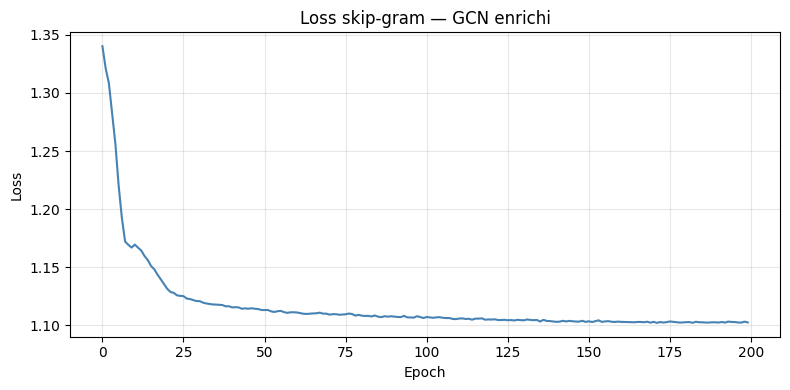

In [75]:
# ── Courbe de loss ────────────────────────────────────────────────────────────
plt.figure(figsize=(8, 4))
plt.plot(history, color='steelblue')
plt.title('Loss skip-gram — GCN enrichi')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 5 — Embeddings, clustering & visualisation

In [77]:
model.eval()
with torch.no_grad():
    z_final = model(x_dev, ei_dev).cpu().numpy()  # (N, 32)

np.save('embeddings_gcn_rich_2_32d.npy', z_final)
print(f'Embeddings sauvegardés : {z_final.shape}')

Embeddings sauvegardés : (146141, 32)


In [78]:
# ── K-Means k=2 ───────────────────────────────────────────────────────────────
kmeans        = KMeans(n_clusters=2, random_state=42, n_init=20)
cluster_labels = kmeans.fit_predict(z_final)

idx_sil = np.random.choice(N, size=min(10000, N), replace=False)
sil     = silhouette_score(z_final[idx_sil], cluster_labels[idx_sil])

print(f'Cluster 0 : {(cluster_labels==0).sum():,} nœuds')
print(f'Cluster 1 : {(cluster_labels==1).sum():,} nœuds')
print(f'Silhouette : {sil:.4f}')

Cluster 0 : 83,130 nœuds
Cluster 1 : 63,011 nœuds
Silhouette : 0.2632


## 6 — Réduction GCN 32D → 2D (projection par réseau de neurones sur graphe)

In [80]:
# ── Projecteur GCN 32D → 2D ─────────────────────────────────────────────────
# On entraîne un second GCN léger qui prend z_final (32D) en entrée
# et apprend à projeter vers 2D en préservant la structure du graphe.
# Loss : reconstruction des distances cosinus entre voisins (neighbor-preserving).

class GCNProjector(nn.Module):
    """
    GCN 2 couches : 32D → hidden → 2D.
    Sortie NON normalisée pour que les coordonnées 2D soient libres dans le plan.
    """
    def __init__(self, in_dim=32, hidden_dim=64, out_dim=2):
        super().__init__()
        self.conv1 = GCNConv(in_dim, hidden_dim)
        self.bn1   = nn.BatchNorm1d(hidden_dim)
        self.conv2 = GCNConv(hidden_dim, out_dim)

    def forward(self, x, edge_index):
        h = F.relu(self.bn1(self.conv1(x, edge_index)))
        h = F.dropout(h, p=0.1, training=self.training)
        return self.conv2(h, edge_index)   # (N, 2) — coordonnées 2D brutes


def neighbor_preserving_loss(z2d, z32d, edge_index, n_neg=5):
    """
    Loss qui force les voisins dans le graphe (proches en 32D)
    à rester proches en 2D, et les non-voisins à s'éloigner.
    - Attractif  : minimise la distance L2 entre nœuds reliés par un arc.
    - Répulsif   : maximise la distance L2 entre nœuds aléatoires (négatifs).
    """
    src, dst = edge_index[0], edge_index[1]

    # Terme attractif : paires de voisins dans le graphe
    d_pos = ((z2d[src] - z2d[dst]) ** 2).sum(dim=1)          # (E,)
    loss_attract = d_pos.mean()

    # Terme répulsif : paires aléatoires (négatifs)
    n_edges = src.shape[0]
    neg_idx = torch.randint(0, z2d.shape[0], (n_edges * n_neg,), device=z2d.device)
    src_rep = src.repeat_interleave(n_neg)
    d_neg   = ((z2d[src_rep] - z2d[neg_idx]) ** 2).sum(dim=1) # (E*n_neg,)
    loss_repul = F.relu(2.0 - d_neg).mean()   # marge = 2.0

    return loss_attract + loss_repul


# ── Hyperparamètres du projecteur ────────────────────────────────────────────
PROJ_EPOCHS  = 100
PROJ_LR      = 5e-3
PROJ_HIDDEN  = 64

# Les embeddings 32D deviennent les features d'entrée du projecteur
z32_tensor = torch.tensor(z_final, dtype=torch.float).to(device)

projector  = GCNProjector(in_dim=EMBED_DIM, hidden_dim=PROJ_HIDDEN, out_dim=2).to(device)
opt_proj   = torch.optim.Adam(projector.parameters(), lr=PROJ_LR, weight_decay=1e-5)
sch_proj   = torch.optim.lr_scheduler.CosineAnnealingLR(opt_proj, T_max=PROJ_EPOCHS)

print(f"Entraînement du projecteur GCN 32D → 2D ({PROJ_EPOCHS} epochs)...")
print(f"{'Epoch':>6}  {'Loss':>8}")
print('-' * 18)

proj_history = []
for epoch in range(1, PROJ_EPOCHS + 1):
    projector.train()
    opt_proj.zero_grad()
    z2d = projector(z32_tensor, ei_dev)          # (N, 2)
    loss = neighbor_preserving_loss(z2d, z32_tensor, ei_dev)
    loss.backward()
    torch.nn.utils.clip_grad_norm_(projector.parameters(), 1.0)
    opt_proj.step()
    sch_proj.step()
    proj_history.append(loss.item())
    if epoch % 10 == 0 or epoch == 1:
        print(f'{epoch:>6}  {loss.item():>8.4f}')

print('\nProjecteur entraîné.')


Entraînement du projecteur GCN 32D → 2D (100 epochs)...
 Epoch      Loss
------------------
     1  323.0760
    10    7.5308
    20    2.7699
    30    2.1768
    40    1.7781
    50    1.6643
    60    1.6452
    70    1.5751
    80    1.5335
    90    1.5436
   100    1.5285

Projecteur entraîné.


Embeddings 2D sauvegardés : (146141, 2)


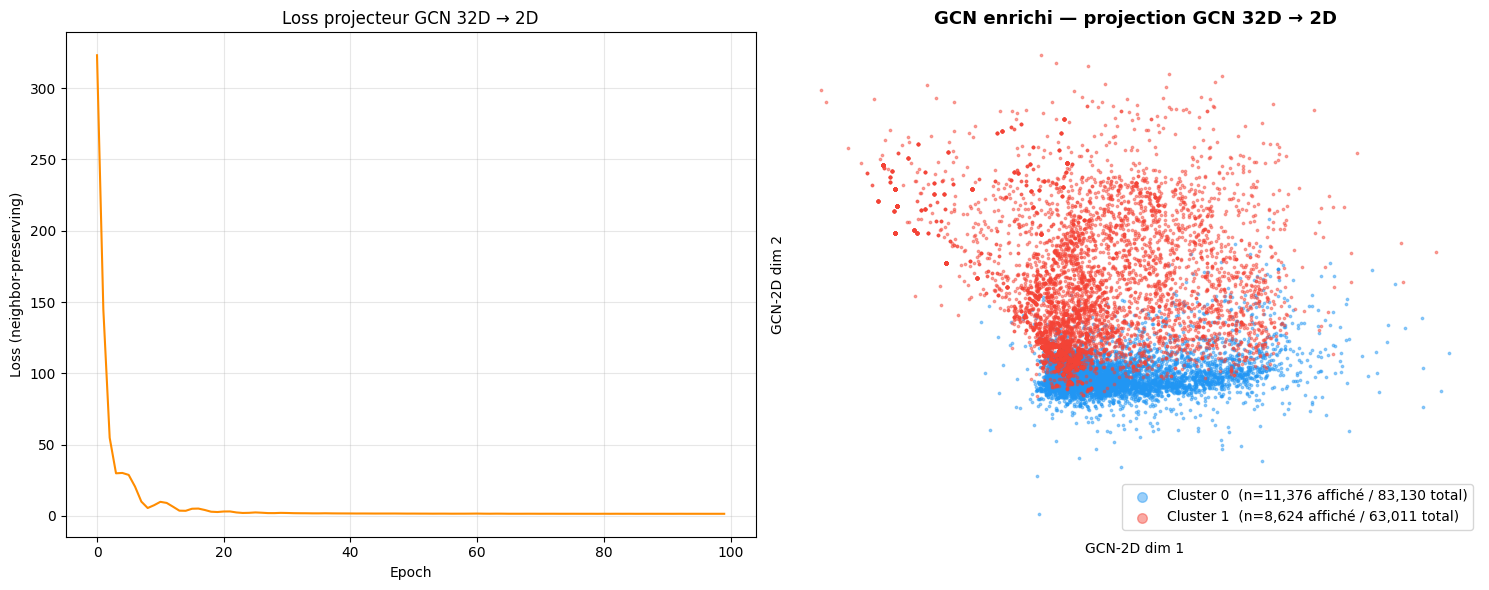

Figure sauvegardée → gcn_rich_2_2d.png


In [81]:
# ── Extraction des coordonnées 2D & visualisation ─────────────────────────────
projector.eval()
with torch.no_grad():
    z_2d = projector(z32_tensor, ei_dev).cpu().numpy()   # (N, 2)

np.save('embeddings_gcn_rich_part2_2d.npy', z_2d)
print(f'Embeddings 2D sauvegardés : {z_2d.shape}')

# Courbe de loss du projecteur
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

axes[0].plot(proj_history, color='darkorange')
axes[0].set_title('Loss projecteur GCN 32D → 2D', fontsize=12)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss (neighbor-preserving)')
axes[0].grid(alpha=0.3)

# Sous-échantillonnage stratifié pour le scatter (matplotlib sature > 20k pts)
VIZ_SIZE = min(20000, N)
idx0 = np.where(cluster_labels == 0)[0]
idx1 = np.where(cluster_labels == 1)[0]
n0   = int(VIZ_SIZE * len(idx0) / N)
sample_idx = np.concatenate([
    np.random.choice(idx0, size=min(n0, len(idx0)),            replace=False),
    np.random.choice(idx1, size=min(VIZ_SIZE - n0, len(idx1)), replace=False)
])

for cid, color in zip([0, 1], ['#2196F3', '#F44336']):
    mask = cluster_labels[sample_idx] == cid
    axes[1].scatter(
        z_2d[sample_idx][mask, 0],
        z_2d[sample_idx][mask, 1],
        c=color, s=3, alpha=0.45,
        label=f'Cluster {cid}  (n={mask.sum():,} affiché / {(cluster_labels==cid).sum():,} total)'
    )

axes[1].legend(markerscale=4, fontsize=10, framealpha=0.8)
axes[1].set_title('GCN enrichi — projection GCN 32D → 2D', fontsize=13, fontweight='bold')
axes[1].set_xlabel('GCN-2D dim 1')
axes[1].set_ylabel('GCN-2D dim 2')
axes[1].set_xticks([]); axes[1].set_yticks([])
for spine in axes[1].spines.values():
    spine.set_visible(False)

plt.tight_layout()
plt.savefig('gcn_rich_2d.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure sauvegardée → gcn_rich_2_2d.png')


In [83]:
# ── Export CSV (32D + 2D GCN + cluster) ───────────────────────────────────────
df_emb = pd.DataFrame(z_final, columns=[f'emb_{i}' for i in range(EMBED_DIM)])
df_emb.insert(0, 'user_id', le.classes_)
df_emb['cluster']  = cluster_labels
df_emb['gcn2d_x']  = z_2d[:, 0]   # coordonnée GCN 2D — axe X
df_emb['gcn2d_y']  = z_2d[:, 1]   # coordonnée GCN 2D — axe Y
df_emb.to_csv('embeddings_gcn_rich_2_2d.csv', index=False)
print(f'Sauvegardé → embeddings_gcn_rich_2.csv  {df_emb.shape}')
print(f'Colonnes : user_id | emb_0..emb_31 | cluster | gcn2d_x | gcn2d_y')


Sauvegardé → embeddings_gcn_rich_2.csv  (146141, 36)
Colonnes : user_id | emb_0..emb_31 | cluster | gcn2d_x | gcn2d_y


In [106]:
## 7 — Validation sur les ancres (Nodes.csv)

Ancres totales : 612
Ancres trouvées dans le graphe : 553  (90.4%)
Ancres absentes du graphe      : 59

⚠️  Polarité inversée détectée — on flip les prédictions (plus cohérent).

═══════════════════════════════════
  Accuracy   : 55.33%
  F1 (macro) : 40.23%
═══════════════════════════════════

                       precision    recall  f1-score   support

Climato-sceptique (0)       0.64      0.06      0.10       253
       Pro-climat (4)       0.55      0.97      0.70       300

             accuracy                           0.55       553
            macro avg       0.59      0.51      0.40       553
         weighted avg       0.59      0.55      0.43       553



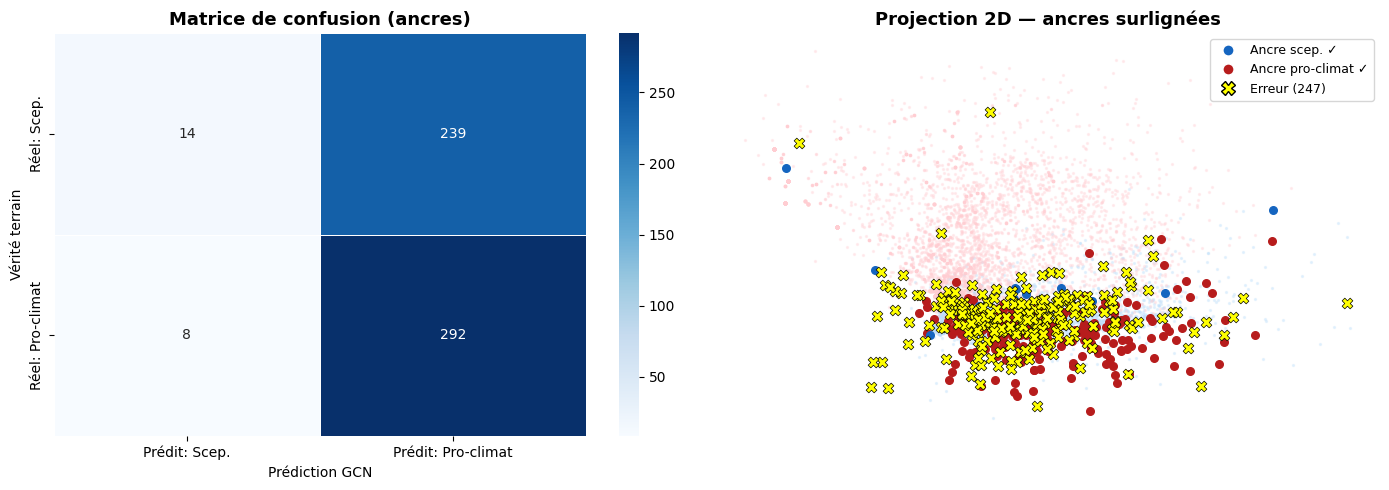

Figure sauvegardée → gcn_validation.png


In [115]:
# ── Validation sur les nœuds ancres (Nodes.csv) ───────────────────────────────
from sklearn.metrics import (
    accuracy_score, f1_score, confusion_matrix, classification_report
)
import matplotlib.pyplot as plt
import seaborn as sns

NODES_PATH = 'Nodes.csv'   

df_nodes = pd.read_csv(NODES_PATH)

# modularity_class : 0 ou 4  →  on mappe en 0/1 pour comparer au cluster_labels
# On garde la correspondance naturelle : modularity 0 → label 0, modularity 4 → label 1
mod_to_binary = {0: 0, 4: 1}
df_nodes['true_label'] = df_nodes['modularity_class'].map(mod_to_binary)

# Construire un dict  node_id → cluster prédit par le GCN
id_to_cluster = dict(zip(le.classes_.astype(str), cluster_labels))

# Aligner : pour chaque ancre présente dans le graphe, récupérer la prédiction
df_nodes['node_id_str'] = df_nodes['Id'].astype(str)
df_nodes['pred_label']  = df_nodes['node_id_str'].map(id_to_cluster)

# Garder uniquement les ancres effectivement dans le graphe
df_val = df_nodes.dropna(subset=['pred_label']).copy()
df_val['pred_label'] = df_val['pred_label'].astype(int)

n_total  = len(df_nodes)
n_found  = len(df_val)
n_missed = n_total - n_found
print(f'Ancres totales : {n_total:,}')
print(f'Ancres trouvées dans le graphe : {n_found:,}  ({100*n_found/n_total:.1f}%)')
print(f'Ancres absentes du graphe      : {n_missed:,}')

y_true = df_val['true_label'].values
y_pred = df_val['pred_label'].values

# ── K-Means n'a pas de notion d'ordre → on teste les 2 polarités ─────────────
# (cluster 0 du GCN peut correspondre au label 0 ou au label 1 de Nodes.csv)
acc_direct  = accuracy_score(y_true, y_pred)
acc_flipped = accuracy_score(y_true, 1 - y_pred)

if acc_flipped > acc_direct:
    print(f'\n⚠️  Polarité inversée détectée — on flip les prédictions (plus cohérent).')
    y_pred = 1 - y_pred
    df_val['pred_label'] = y_pred

acc = accuracy_score(y_true, y_pred)
f1  = f1_score(y_true, y_pred, average='macro')

print(f'\n═══════════════════════════════════')
print(f'  Accuracy   : {acc*100:.2f}%')
print(f'  F1 (macro) : {f1*100:.2f}%')
print(f'═══════════════════════════════════')
print()
print(classification_report(
    y_true, y_pred,
    target_names=['Climato-sceptique (0)', 'Pro-climat (4)']
))

# ── Matrice de confusion ──────────────────────────────────────────────────────
cm = confusion_matrix(y_true, y_pred)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=['Prédit: Scep.', 'Prédit: Pro-climat'],
    yticklabels=['Réel: Scep.', 'Réel: Pro-climat'],
    ax=axes[0], linewidths=.5
)
axes[0].set_title('Matrice de confusion (ancres)', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Vérité terrain')
axes[0].set_xlabel('Prédiction GCN')

# ── Visualisation 2D avec ancres surlignées ───────────────────────────────────
# Fond : tous les nœuds (sous-échantillon)
VIZ_SIZE = min(15000, N)
sample_idx = np.random.choice(N, size=VIZ_SIZE, replace=False)
for cid, color in zip([0, 1], ['#BBDEFB', '#FFCDD2']):
    mask = cluster_labels[sample_idx] == cid
    axes[1].scatter(
        z_2d[sample_idx][mask, 0],
        z_2d[sample_idx][mask, 1],
        c=color, s=2, alpha=0.3
    )

# Ancres correctement classées
df_ok  = df_val[df_val['true_label'] == df_val['pred_label']]
df_err = df_val[df_val['true_label'] != df_val['pred_label']]

for row in df_ok.itertuples():
    node_idx = np.where(le.classes_.astype(str) == row.node_id_str)[0]
    if len(node_idx):
        ni = node_idx[0]
        color = '#1565C0' if row.pred_label == 0 else '#B71C1C'
        axes[1].scatter(z_2d[ni, 0], z_2d[ni, 1], c=color, s=30, zorder=5)

for row in df_err.itertuples():
    node_idx = np.where(le.classes_.astype(str) == row.node_id_str)[0]
    if len(node_idx):
        ni = node_idx[0]
        axes[1].scatter(z_2d[ni, 0], z_2d[ni, 1],
                        c='yellow', s=60, marker='X', zorder=6,
                        edgecolors='black', linewidths=0.5)

# Légende manuelle
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0],[0], marker='o', color='w', markerfacecolor='#1565C0', markersize=8, label='Ancre scep. ✓'),
    Line2D([0],[0], marker='o', color='w', markerfacecolor='#B71C1C', markersize=8, label='Ancre pro-climat ✓'),
    Line2D([0],[0], marker='X', color='w', markerfacecolor='yellow',  markersize=10,
           markeredgecolor='black', label=f'Erreur ({len(df_err)})')
]
axes[1].legend(handles=legend_elements, fontsize=9, loc='best', framealpha=0.8)
axes[1].set_title('Projection 2D — ancres surlignées', fontsize=13, fontweight='bold')
axes[1].set_xticks([]); axes[1].set_yticks([])
for spine in axes[1].spines.values():
    spine.set_visible(False)

plt.tight_layout()
plt.savefig('gcn_validation.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Figure sauvegardée → gcn_validation.png')
